# KNU 2026 ML Final Assignment — p3
## Improvements over p2 (OOF BA 0.90851):
1. **Jerk features** — first derivative of acceleration/gyro → captures explosive impulses (JumpSquat takeoff/landing, MtnClimb rapid legs)
2. **Per-PID rest-baseline normalization** — divide each subject's features by their own rest-segment statistics → subject-independent features, fixes fold variance
3. **Lateral asymmetry features** — skewness + asymmetry index on body-frame xb axis → separates Lunge (asymmetric) from Squat (symmetric)
4. **Soft probability rolling window** — replace hard majority-vote with 5s rolling average of softmax probabilities per PID → directly attacks 823 Rest-contamination errors
5. **LGBM hyperparameter fix** — lr=0.1, early_stopping=50 → stops LGBM underfitting (was stopping at 44–109 rounds)
6. **Unknown device normalization** — fallback to global train stats for test-set `unknown` device rows


In [1]:
!pip install lightgbm catboost scikit-learn pandas numpy scipy -q


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
from scipy.fft import rfft, rfftfreq
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score

import lightgbm as lgb
import catboost as cb

import os


In [3]:
# ── Configuration ──────────────────────────────────────────
DATA_DIR = '/Users/dayana/git repo/machine-learning-class/lab6/knu-2026-machine-learning-final-assignment'
SEED     = 42
N_FOLDS  = 5

# p3 fix: lr=0.1 (was 0.05), early_stopping=50 (was 100) → stops LGBM underfitting
LGBM_PARAMS = {
    'objective':        'multiclass',
    'num_class':        9,
    'metric':           'multi_logloss',
    'learning_rate':    0.1,       # ← was 0.05
    'num_leaves':       127,
    'max_depth':        -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     1,
    'lambda_l1':        0.1,
    'lambda_l2':        0.1,
    'verbose':          -1,
    'n_jobs':           -1,
    'seed':             SEED,
}

CAT_PARAMS = {
    'iterations':           2000,
    'learning_rate':        0.05,
    'depth':                8,
    'l2_leaf_reg':          3,
    'loss_function':        'MultiClass',
    'eval_metric':          'TotalF1:average=Macro',
    'early_stopping_rounds': 150,
    'random_seed':          SEED,
    'verbose':              0,
}

print("Config loaded.")


Config loaded.


In [4]:
# ── Load Raw Data ───────────────────────────────────────────
print("Loading sensor files (this may take ~1-2 minutes)...")

train_accel = pd.read_csv(os.path.join(DATA_DIR, 'train-accel.csv'))
train_gyro  = pd.read_csv(os.path.join(DATA_DIR, 'train-gyro.csv'))
train_label = pd.read_csv(os.path.join(DATA_DIR, 'train-label.csv'))

test_accel  = pd.read_csv(os.path.join(DATA_DIR, 'test-accel.csv'))
test_gyro   = pd.read_csv(os.path.join(DATA_DIR, 'test-gyro.csv'))
test_label  = pd.read_csv(os.path.join(DATA_DIR, 'test-label.csv'))

print(f"train_accel : {train_accel.shape}")
print(f"train_gyro  : {train_gyro.shape}")
print(f"train_label : {train_label.shape}")
print(f"test_accel  : {test_accel.shape}")
print(f"test_gyro   : {test_gyro.shape}")
print(f"test_label  : {test_label.shape}")


Loading sensor files (this may take ~1-2 minutes)...
train_accel : (2428374, 7)
train_gyro  : (2433673, 7)
train_label : (38015, 4)
test_accel  : (2528310, 7)
test_gyro   : (2541831, 7)
test_label  : (39473, 4)


In [5]:
# ── Improvement 6: Device Normalization + Unknown Device Fallback ────────────
# p2 problem: test set has 'unknown' device not seen in train → no normalization applied.
# p3 fix: compute global (all-device) train stats as fallback for unseen devices.

def normalize_by_device(df_train, df_test, axes=['x', 'y', 'z']):
    """
    Z-score normalize sensor axes per device using train statistics.
    p3: unknown/unseen test devices fall back to global train mean/std.
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()

    # Pre-compute global fallback stats from ALL train rows
    global_stats = {}
    for ax in axes:
        global_stats[ax] = (df_train[ax].mean(), df_train[ax].std() + 1e-8)

    # Per-device normalization
    known_devices = set(df_train['device'].unique())
    for device in known_devices:
        tr_mask = df_train['device'] == device
        te_mask = df_test['device'] == device
        for ax in axes:
            mu  = df_train.loc[tr_mask, ax].mean()
            sig = df_train.loc[tr_mask, ax].std() + 1e-8
            df_train.loc[tr_mask, ax] = (df_train.loc[tr_mask, ax] - mu) / sig
            df_test.loc[te_mask,  ax] = (df_test.loc[te_mask,  ax] - mu) / sig

    # Fallback: normalize test rows whose device was NOT in train
    unknown_mask = ~df_test['device'].isin(known_devices)
    if unknown_mask.sum() > 0:
        print(f"  Applying global fallback normalization to {unknown_mask.sum()} rows "
              f"with unseen device(s): {df_test.loc[unknown_mask, 'device'].unique()}")
        for ax in axes:
            mu, sig = global_stats[ax]
            df_test.loc[unknown_mask, ax] = (df_test.loc[unknown_mask, ax] - mu) / sig

    return df_train, df_test

print("Normalizing accel by device...")
train_accel, test_accel = normalize_by_device(train_accel, test_accel)

print("Normalizing gyro by device...")
train_gyro, test_gyro = normalize_by_device(train_gyro, test_gyro)

print("Device normalization done.")
print(f"  Devices in train_accel: {train_accel['device'].unique()}")
print(f"  Devices in test_accel : {test_accel['device'].unique()}")


Normalizing accel by device...
  Applying global fallback normalization to 92768 rows with unseen device(s): <StringArray>
['unknown']
Length: 1, dtype: str
Normalizing gyro by device...
  Applying global fallback normalization to 92737 rows with unseen device(s): <StringArray>
['unknown']
Length: 1, dtype: str
Device normalization done.
  Devices in train_accel: <StringArray>
['samsung', 'Apple']
Length: 2, dtype: str
  Devices in test_accel : <StringArray>
['unknown', 'samsung', 'Apple']
Length: 3, dtype: str


In [6]:
# ── Direction-Corrected Axes (unchanged from p2) ────────────
def apply_direction_correction(df):
    """
    Rotate x, y, z into canonical body frame based on phone direction.
    Adds columns: xb (lateral), yb (forward/back), zb (vertical), magb.
    """
    df = df.copy()
    df['xb'] = df['x'].copy()
    df['yb'] = df['y'].copy()
    df['zb'] = df['z'].copy()

    for d, (sx, sy, sz) in {
        1: ( 'y', '-x',  'z'),
        2: ('-y',  'x',  'z'),
        3: ( 'y', '-x', '-z'),
        4: ('-y',  'x', '-z'),
    }.items():
        mask = df['direction'] == d
        df.loc[mask, 'xb'] = (df.loc[mask, 'x'] if sx == 'x'
                               else -df.loc[mask, 'x'] if sx == '-x'
                               else  df.loc[mask, 'y'] if sx == 'y'
                               else -df.loc[mask, 'y'])
        df.loc[mask, 'yb'] = (df.loc[mask, 'x'] if sy == 'x'
                               else -df.loc[mask, 'x'] if sy == '-x'
                               else  df.loc[mask, 'y'] if sy == 'y'
                               else -df.loc[mask, 'y'])
        df.loc[mask, 'zb'] = (df.loc[mask, 'z'] if sz == 'z'
                               else -df.loc[mask, 'z'])

    df['magb'] = np.sqrt(df['xb']**2 + df['yb']**2 + df['zb']**2)
    return df

print("Applying direction correction to accel...")
train_accel = apply_direction_correction(train_accel)
test_accel  = apply_direction_correction(test_accel)

print("Applying direction correction to gyro...")
train_gyro  = apply_direction_correction(train_gyro)
test_gyro   = apply_direction_correction(test_gyro)

print("Direction correction done.")
print("Sample accel after correction:")
print(train_accel[['direction','x','y','z','xb','yb','zb','magb']].head(4))


Applying direction correction to accel...
Applying direction correction to gyro...
Direction correction done.
Sample accel after correction:
   direction         x         y         z        xb        yb        zb  \
0        1.0  0.745617  0.275943  0.651492  0.275943 -0.745617  0.651492   
1        1.0  0.742578  0.250713  0.667765  0.250713 -0.742578  0.667765   
2        1.0  0.748189  0.216309  0.660485  0.216309 -0.748189  0.660485   
3        1.0  0.754735  0.227777  0.643784  0.227777 -0.754735  0.643784   

       magb  
0  1.027877  
1  1.029654  
2  1.021184  
3  1.017824  


In [7]:
# ── Feature Extraction Helpers ──────────────────────────────
FS = 50.0  # nominal sampling rate in Hz

# ────────────────────────────────────────────────────────────
# STAT FEATURES  (unchanged from p2 — 17 per channel)
# ────────────────────────────────────────────────────────────
def stat_features(arr, prefix):
    feats = {}
    n = len(arr)
    if n == 0:
        for k in ['mean','std','var','min','max','range','median',
                  'p25','p75','iqr','skew','kurt','rms','energy',
                  'zero_cross','mean_abs_diff','max_abs']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats
    feats[f'{prefix}_mean']          = np.mean(arr)
    feats[f'{prefix}_std']           = np.std(arr)
    feats[f'{prefix}_var']           = np.var(arr)
    feats[f'{prefix}_min']           = np.min(arr)
    feats[f'{prefix}_max']           = np.max(arr)
    feats[f'{prefix}_range']         = np.ptp(arr)
    feats[f'{prefix}_median']        = np.median(arr)
    feats[f'{prefix}_p25']           = np.percentile(arr, 25)
    feats[f'{prefix}_p75']           = np.percentile(arr, 75)
    feats[f'{prefix}_iqr']           = np.percentile(arr, 75) - np.percentile(arr, 25)
    feats[f'{prefix}_skew']          = float(stats.skew(arr))     if n > 2 else 0.0
    feats[f'{prefix}_kurt']          = float(stats.kurtosis(arr)) if n > 2 else 0.0
    feats[f'{prefix}_rms']           = np.sqrt(np.mean(arr**2))
    feats[f'{prefix}_energy']        = np.sum(arr**2) / n
    feats[f'{prefix}_zero_cross']    = np.sum(np.diff(np.sign(arr - np.mean(arr))) != 0) / max(n-1, 1)
    feats[f'{prefix}_mean_abs_diff'] = np.mean(np.abs(np.diff(arr))) if n > 1 else 0.0
    feats[f'{prefix}_max_abs']       = np.max(np.abs(arr))
    return feats


# ────────────────────────────────────────────────────────────
# FFT FEATURES  (unchanged from p2 — 7 per channel)
# ────────────────────────────────────────────────────────────
def fft_features(arr, prefix, fs=FS):
    feats = {}
    n = len(arr)
    if n < 8:
        for k in ['dom_freq','dom_amp','spectral_entropy',
                  'band_low','band_mid','band_high','band_ratio_mid_low']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    arr_centered = arr - np.mean(arr)
    fft_vals = np.abs(rfft(arr_centered))
    freqs    = rfftfreq(n, d=1.0/fs)
    total_power = np.sum(fft_vals**2) + 1e-10

    dom_idx = np.argmax(fft_vals)
    feats[f'{prefix}_dom_freq'] = freqs[dom_idx]
    feats[f'{prefix}_dom_amp']  = fft_vals[dom_idx]

    psd_norm = fft_vals**2 / total_power
    psd_norm = psd_norm[psd_norm > 0]
    feats[f'{prefix}_spectral_entropy'] = -np.sum(psd_norm * np.log(psd_norm + 1e-10))

    low_mask  = (freqs >= 0.0) & (freqs < 1.0)
    mid_mask  = (freqs >= 1.0) & (freqs < 3.0)
    high_mask = (freqs >= 3.0) & (freqs < 8.0)

    feats[f'{prefix}_band_low']  = np.sum(fft_vals[low_mask]**2)  / total_power
    feats[f'{prefix}_band_mid']  = np.sum(fft_vals[mid_mask]**2)  / total_power
    feats[f'{prefix}_band_high'] = np.sum(fft_vals[high_mask]**2) / total_power
    feats[f'{prefix}_band_ratio_mid_low'] = (
        feats[f'{prefix}_band_mid'] / (feats[f'{prefix}_band_low'] + 1e-10)
    )
    return feats


# ────────────────────────────────────────────────────────────
# PEAK FEATURES  (unchanged from p2 — 6 per channel)
# ────────────────────────────────────────────────────────────
def peak_features(arr, prefix, fs=FS):
    feats = {}
    n = len(arr)
    if n < 4:
        for k in ['n_peaks','peak_rate','mean_peak_height',
                  'std_peak_height','mean_peak_interval','peak_regularity']:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    arr_centered  = arr - np.mean(arr)
    height_thresh = 0.3 * np.std(arr_centered)
    peaks, props  = find_peaks(arr_centered,
                                height=height_thresh,
                                distance=int(fs * 0.15))
    n_peaks    = len(peaks)
    duration_s = n / fs

    feats[f'{prefix}_n_peaks']   = n_peaks
    feats[f'{prefix}_peak_rate'] = n_peaks / duration_s

    if n_peaks > 0:
        ph = props['peak_heights']
        feats[f'{prefix}_mean_peak_height'] = np.mean(ph)
        feats[f'{prefix}_std_peak_height']  = np.std(ph)
    else:
        feats[f'{prefix}_mean_peak_height'] = 0.0
        feats[f'{prefix}_std_peak_height']  = 0.0

    if n_peaks > 1:
        intervals = np.diff(peaks) / fs
        feats[f'{prefix}_mean_peak_interval'] = np.mean(intervals)
        feats[f'{prefix}_peak_regularity']    = 1.0 / (np.std(intervals) + 1e-6)
    else:
        feats[f'{prefix}_mean_peak_interval'] = 0.0
        feats[f'{prefix}_peak_regularity']    = 0.0

    return feats


# ────────────────────────────────────────────────────────────
# POSTURE FEATURES  (unchanged from p2 — 5 features)
# ────────────────────────────────────────────────────────────
def posture_features(a_xb, a_yb, a_zb):
    feats = {}
    if len(a_xb) == 0:
        feats.update({
            'posture_zb_mean': 0.0, 'posture_yb_mean': 0.0,
            'posture_tilt_angle': 0.0, 'posture_prone_score': 0.0,
            'posture_vertical_energy': 0.0,
        })
        return feats

    grav_x = np.mean(a_xb)
    grav_y = np.mean(a_yb)
    grav_z = np.mean(a_zb)
    grav_mag = np.sqrt(grav_x**2 + grav_y**2 + grav_z**2) + 1e-8

    feats['posture_zb_mean']        = grav_z
    feats['posture_yb_mean']        = grav_y
    feats['posture_tilt_angle']     = np.arccos(np.clip(abs(grav_y) / grav_mag, 0, 1))
    feats['posture_prone_score']    = abs(grav_z) / grav_mag
    dynamic_zb = np.array(a_zb) - grav_z
    feats['posture_vertical_energy'] = np.mean(dynamic_zb**2)
    return feats


# ────────────────────────────────────────────────────────────
# NEW p3 — JERK FEATURES  (Priority 1)
# First derivative of acceleration = jerk.
# JumpSquat: huge jerk at takeoff + landing.
# MtnClimb: rapid small jerks from alternating legs.
# PushUp:   slow smooth jerk (no impulse).
# Squat:    low smooth jerk.
# Rest:     near-zero jerk.
# We extract stat features on the jerk signal (13 features per channel).
# ────────────────────────────────────────────────────────────
def jerk_features(arr, prefix, fs=FS):
    """
    Compute jerk (d/dt of signal) and extract key statistics.
    Uses 13 features: mean_abs, std, max_abs, rms, energy,
    p90_abs, p95_abs, skew, kurt, n_peaks, peak_rate,
    mean_peak_height, impulse_ratio.
    """
    feats = {}
    keys = ['mean_abs','std','max_abs','rms','energy',
            'p90_abs','p95_abs','skew','kurt',
            'n_peaks','peak_rate','mean_peak_height','impulse_ratio']
    if len(arr) < 2:
        for k in keys:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    jerk = np.diff(arr.astype(np.float64)) * fs   # units per second²
    n    = len(jerk)

    feats[f'{prefix}_mean_abs']  = np.mean(np.abs(jerk))
    feats[f'{prefix}_std']       = np.std(jerk)
    feats[f'{prefix}_max_abs']   = np.max(np.abs(jerk))
    feats[f'{prefix}_rms']       = np.sqrt(np.mean(jerk**2))
    feats[f'{prefix}_energy']    = np.sum(jerk**2) / n
    feats[f'{prefix}_p90_abs']   = np.percentile(np.abs(jerk), 90)
    feats[f'{prefix}_p95_abs']   = np.percentile(np.abs(jerk), 95)
    feats[f'{prefix}_skew']      = float(stats.skew(jerk))     if n > 2 else 0.0
    feats[f'{prefix}_kurt']      = float(stats.kurtosis(jerk)) if n > 2 else 0.0

    # Peaks in |jerk| — captures explosive impulses
    abs_jerk = np.abs(jerk)
    thresh   = 0.5 * np.std(abs_jerk)
    peaks, props = find_peaks(abs_jerk, height=thresh, distance=int(fs * 0.1))
    n_peaks    = len(peaks)
    duration_s = n / fs
    feats[f'{prefix}_n_peaks']   = n_peaks
    feats[f'{prefix}_peak_rate'] = n_peaks / duration_s
    feats[f'{prefix}_mean_peak_height'] = (
        np.mean(props['peak_heights']) if n_peaks > 0 else 0.0
    )
    # Impulse ratio: max jerk / mean jerk — high for jump exercises, low for smooth ones
    mean_abs = feats[f'{prefix}_mean_abs'] + 1e-10
    feats[f'{prefix}_impulse_ratio'] = feats[f'{prefix}_max_abs'] / mean_abs

    return feats


# ────────────────────────────────────────────────────────────
# NEW p3 — LATERAL ASYMMETRY FEATURES  (Priority 3)
# Body-frame xb axis = lateral (left-right) direction.
# Lunge: unilateral weight shift → large xb skewness, high asymmetry index.
# Squat: bilateral, symmetric → xb skewness near zero.
# JumpSquat: symmetric jump → low xb asymmetry.
# 6 features per call.
# ────────────────────────────────────────────────────────────
def lateral_asymmetry_features(axb, prefix='lat'):
    """
    Lateral axis (xb) asymmetry features to separate Lunge from Squat/JumpSquat.
    """
    feats = {}
    keys = ['xb_skew','xb_kurt','xb_asymmetry_idx',
            'xb_pos_ratio','xb_range_ratio','xb_mean_abs']
    if len(axb) < 4:
        for k in keys:
            feats[f'{prefix}_{k}'] = 0.0
        return feats

    arr = np.array(axb, dtype=np.float64)
    m   = np.mean(arr)
    arr_c = arr - m

    feats[f'{prefix}_xb_skew']  = float(stats.skew(arr_c))     if len(arr) > 2 else 0.0
    feats[f'{prefix}_xb_kurt']  = float(stats.kurtosis(arr_c)) if len(arr) > 2 else 0.0

    # Asymmetry index: (mean_positive - |mean_negative|) / (mean_positive + |mean_negative| + 1e-8)
    pos_vals = arr_c[arr_c > 0]
    neg_vals = arr_c[arr_c < 0]
    mean_pos = np.mean(pos_vals)  if len(pos_vals) > 0 else 0.0
    mean_neg = np.mean(neg_vals)  if len(neg_vals) > 0 else 0.0  # negative value
    feats[f'{prefix}_xb_asymmetry_idx'] = (
        (mean_pos + mean_neg) / (abs(mean_pos) + abs(mean_neg) + 1e-8)
    )

    # Fraction of samples on positive (right) side
    feats[f'{prefix}_xb_pos_ratio'] = len(pos_vals) / len(arr)

    # Range asymmetry: max / (|min| + 1e-8) — balanced squat ≈ 1, lunge > 1 or < 1
    feats[f'{prefix}_xb_range_ratio'] = np.max(arr_c) / (abs(np.min(arr_c)) + 1e-8)

    feats[f'{prefix}_xb_mean_abs']    = np.mean(np.abs(arr_c))

    return feats


print("Feature extraction helpers defined.")
print(f"  stat_features              : 17 per channel (unchanged)")
print(f"  fft_features               : 7  per channel (unchanged)")
print(f"  peak_features              : 6  per channel (unchanged)")
print(f"  posture_features           : 5  (unchanged)")
print(f"  jerk_features    [NEW p3]  : 13 per channel")
print(f"  lateral_asymmetry [NEW p3] : 6")


Feature extraction helpers defined.
  stat_features              : 17 per channel (unchanged)
  fft_features               : 7  per channel (unchanged)
  peak_features              : 6  per channel (unchanged)
  posture_features           : 5  (unchanged)
  jerk_features    [NEW p3]  : 13 per channel
  lateral_asymmetry [NEW p3] : 6


In [8]:
# ── Main Feature Extraction Function — p3 ───────────────────
CONTEXT_SHORT = 1   # ±1s for stat features
CONTEXT_LONG  = 4   # ±4s for FFT, peak, jerk features

def compute_features_p3(accel_df, gyro_df, label_df):
    """
    Extract all p3 features for each (pid, time_s) in label_df.
    New vs p2:
      - jerk features on amag, axb, ayb, azb (short + long windows)
      - lateral asymmetry features on axb (short + long windows)
    """
    accel_df = accel_df.copy()
    gyro_df  = gyro_df.copy()
    label_df = label_df.copy()

    accel_df['time_s'] = accel_df['time'].astype(int)
    gyro_df['time_s']  = gyro_df['time'].astype(int)
    label_df['time_s'] = label_df['time'].astype(int)

    for df in [accel_df, gyro_df]:
        df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

    print("  Building sensor lookup tables...")

    def build_lookup(df, cols):
        lookup = {}
        for (pid, ts), grp in df.groupby(['pid', 'time_s']):
            lookup[(pid, ts)] = grp[cols].values
        return lookup

    accel_raw_lookup  = build_lookup(accel_df, ['x','y','z','mag'])
    accel_body_lookup = build_lookup(accel_df, ['xb','yb','zb','magb'])
    gyro_raw_lookup   = build_lookup(gyro_df,  ['x','y','z','mag'])
    gyro_body_lookup  = build_lookup(gyro_df,  ['xb','yb','zb','magb'])

    meta_lookup = {}
    for (pid, ts), grp in accel_df.groupby(['pid', 'time_s']):
        meta_lookup[(pid, ts)] = {
            'direction': grp['direction'].iloc[0],
            'device':    1 if str(grp['device'].iloc[0]).lower() == 'apple' else 0,
        }

    print("  Extracting features per label row (this takes a few minutes)...")
    all_feats = []

    for idx, (_, row) in enumerate(label_df.iterrows()):
        pid = row['pid']
        ts  = int(row['time_s'])
        feat = {}

        # ── Collect SHORT window arrays (±1s)
        ax_s, ay_s, az_s, amag_s      = [], [], [], []
        gx_s, gy_s, gz_s, gmag_s      = [], [], [], []
        axb_s, ayb_s, azb_s            = [], [], []

        for offset in range(-CONTEXT_SHORT, CONTEXT_SHORT + 1):
            key = (pid, ts + offset)
            if key in accel_raw_lookup:
                c = accel_raw_lookup[key]
                ax_s.extend(c[:,0]); ay_s.extend(c[:,1])
                az_s.extend(c[:,2]); amag_s.extend(c[:,3])
            if key in accel_body_lookup:
                c = accel_body_lookup[key]
                axb_s.extend(c[:,0]); ayb_s.extend(c[:,1]); azb_s.extend(c[:,2])
            if key in gyro_raw_lookup:
                c = gyro_raw_lookup[key]
                gx_s.extend(c[:,0]); gy_s.extend(c[:,1])
                gz_s.extend(c[:,2]); gmag_s.extend(c[:,3])

        # ── Collect LONG window arrays (±4s)
        amag_l, axb_l, ayb_l, azb_l   = [], [], [], []
        gmag_l, gxb_l, gyb_l, gzb_l   = [], [], [], []

        for offset in range(-CONTEXT_LONG, CONTEXT_LONG + 1):
            key = (pid, ts + offset)
            if key in accel_raw_lookup:
                c = accel_raw_lookup[key]; amag_l.extend(c[:,3])
            if key in accel_body_lookup:
                c = accel_body_lookup[key]
                axb_l.extend(c[:,0]); ayb_l.extend(c[:,1]); azb_l.extend(c[:,2])
            if key in gyro_raw_lookup:
                c = gyro_raw_lookup[key]; gmag_l.extend(c[:,3])
            if key in gyro_body_lookup:
                c = gyro_body_lookup[key]
                gxb_l.extend(c[:,0]); gyb_l.extend(c[:,1]); gzb_l.extend(c[:,2])

        # numpy conversion
        ax_s   = np.array(ax_s,   dtype=np.float32)
        ay_s   = np.array(ay_s,   dtype=np.float32)
        az_s   = np.array(az_s,   dtype=np.float32)
        amag_s = np.array(amag_s, dtype=np.float32)
        gx_s   = np.array(gx_s,   dtype=np.float32)
        gy_s   = np.array(gy_s,   dtype=np.float32)
        gz_s   = np.array(gz_s,   dtype=np.float32)
        gmag_s = np.array(gmag_s, dtype=np.float32)
        axb_s  = np.array(axb_s,  dtype=np.float32)
        ayb_s  = np.array(ayb_s,  dtype=np.float32)
        azb_s  = np.array(azb_s,  dtype=np.float32)

        amag_l = np.array(amag_l, dtype=np.float32)
        axb_l  = np.array(axb_l,  dtype=np.float32)
        ayb_l  = np.array(ayb_l,  dtype=np.float32)
        azb_l  = np.array(azb_l,  dtype=np.float32)
        gmag_l = np.array(gmag_l, dtype=np.float32)
        gxb_l  = np.array(gxb_l,  dtype=np.float32)
        gyb_l  = np.array(gyb_l,  dtype=np.float32)
        gzb_l  = np.array(gzb_l,  dtype=np.float32)

        # ════════════════════════════════════════════════════
        # STAT FEATURES  (short window ±1s)  — unchanged
        # ════════════════════════════════════════════════════
        feat.update(stat_features(ax_s,   'ax'))
        feat.update(stat_features(ay_s,   'ay'))
        feat.update(stat_features(az_s,   'az'))
        feat.update(stat_features(amag_s, 'amag'))
        feat.update(stat_features(axb_s,  'axb'))
        feat.update(stat_features(ayb_s,  'ayb'))
        feat.update(stat_features(azb_s,  'azb'))
        feat.update(stat_features(gx_s,   'gx'))
        feat.update(stat_features(gy_s,   'gy'))
        feat.update(stat_features(gz_s,   'gz'))
        feat.update(stat_features(gmag_s, 'gmag'))

        # Cross-sensor correlation
        if len(amag_s) > 2 and len(gmag_s) > 2:
            ml = min(len(amag_s), len(gmag_s))
            feat['accel_gyro_mag_corr'] = float(np.corrcoef(amag_s[:ml], gmag_s[:ml])[0,1])
        else:
            feat['accel_gyro_mag_corr'] = 0.0

        # ════════════════════════════════════════════════════
        # FFT FEATURES  (long window ±4s)  — unchanged
        # ════════════════════════════════════════════════════
        feat.update(fft_features(amag_l, 'amag_fft'))
        feat.update(fft_features(axb_l,  'axb_fft'))
        feat.update(fft_features(ayb_l,  'ayb_fft'))
        feat.update(fft_features(azb_l,  'azb_fft'))
        feat.update(fft_features(gmag_l, 'gmag_fft'))
        feat.update(fft_features(gxb_l,  'gxb_fft'))
        feat.update(fft_features(gyb_l,  'gyb_fft'))
        feat.update(fft_features(gzb_l,  'gzb_fft'))

        # ════════════════════════════════════════════════════
        # PEAK FEATURES  (long window ±4s)  — unchanged
        # ════════════════════════════════════════════════════
        feat.update(peak_features(amag_l, 'amag_pk'))
        feat.update(peak_features(axb_l,  'axb_pk'))
        feat.update(peak_features(ayb_l,  'ayb_pk'))
        feat.update(peak_features(azb_l,  'azb_pk'))
        feat.update(peak_features(gmag_l, 'gmag_pk'))

        # ════════════════════════════════════════════════════
        # POSTURE FEATURES  (body-frame short window) — unchanged
        # ════════════════════════════════════════════════════
        feat.update(posture_features(axb_s, ayb_s, azb_s))

        # ════════════════════════════════════════════════════
        # NEW p3: JERK FEATURES  (Priority 1)
        # Short window: captures within-rep explosive moments
        # Long window:  captures overall movement character
        # ════════════════════════════════════════════════════
        feat.update(jerk_features(amag_s, 'amag_jerk_s'))   # short — accel magnitude
        feat.update(jerk_features(axb_s,  'axb_jerk_s'))    # short — lateral jerk
        feat.update(jerk_features(ayb_s,  'ayb_jerk_s'))    # short — forward jerk
        feat.update(jerk_features(azb_s,  'azb_jerk_s'))    # short — vertical jerk
        feat.update(jerk_features(gmag_s, 'gmag_jerk_s'))   # short — gyro magnitude jerk

        feat.update(jerk_features(amag_l, 'amag_jerk_l'))   # long — captures full jump arc
        feat.update(jerk_features(azb_l,  'azb_jerk_l'))    # long — vertical jump impulse
        feat.update(jerk_features(axb_l,  'axb_jerk_l'))    # long — lateral impulse (lunge step)

        # ════════════════════════════════════════════════════
        # NEW p3: LATERAL ASYMMETRY FEATURES  (Priority 3)
        # Short window: within-second lateral balance
        # Long window:  overall lateral bias of the movement
        # ════════════════════════════════════════════════════
        feat.update(lateral_asymmetry_features(axb_s, prefix='lat_s'))  # short window
        feat.update(lateral_asymmetry_features(axb_l, prefix='lat_l'))  # long window

        # ════════════════════════════════════════════════════
        # GRAVITY + TILT  — unchanged
        # ════════════════════════════════════════════════════
        if len(ax_s) > 0:
            feat['gravity_x']   = float(np.mean(ax_s))
            feat['gravity_y']   = float(np.mean(ay_s))
            feat['gravity_z']   = float(np.mean(az_s))
            gm = np.sqrt(feat['gravity_x']**2 + feat['gravity_y']**2 + feat['gravity_z']**2)
            feat['gravity_mag'] = gm
            feat['tilt_xz']     = float(np.arctan2(feat['gravity_x'], feat['gravity_z'])) if gm > 0 else 0.0
            feat['tilt_yz']     = float(np.arctan2(feat['gravity_y'], feat['gravity_z'])) if gm > 0 else 0.0
        else:
            feat.update({'gravity_x':0,'gravity_y':0,'gravity_z':0,
                         'gravity_mag':0,'tilt_xz':0,'tilt_yz':0})

        # Data quality
        feat['n_accel_samples'] = len(ax_s)
        feat['n_gyro_samples']  = len(gx_s)

        # Metadata
        if (pid, ts) in meta_lookup:
            feat['direction'] = meta_lookup[(pid, ts)]['direction']
            feat['device']    = meta_lookup[(pid, ts)]['device']
        else:
            feat['direction'] = -1
            feat['device']    = -1

        all_feats.append(feat)

        if (idx + 1) % 5000 == 0:
            print(f"    {idx+1}/{len(label_df)} rows done...")

    feat_df = pd.DataFrame(all_feats)
    feat_df.index = label_df.index
    return feat_df

print("Feature extraction function defined.")


Feature extraction function defined.


In [9]:
# ── Run Feature Extraction ───────────────────────────────────
print("Extracting TRAIN features...")
train_feats = compute_features_p3(train_accel, train_gyro, train_label)
print(f"Train features shape: {train_feats.shape}")

print("\nExtracting TEST features...")
test_feats = compute_features_p3(test_accel, test_gyro, test_label)
print(f"Test features shape: {test_feats.shape}")


Extracting TRAIN features...
  Building sensor lookup tables...
  Extracting features per label row (this takes a few minutes)...
    5000/38015 rows done...
    10000/38015 rows done...
    15000/38015 rows done...
    20000/38015 rows done...
    25000/38015 rows done...
    30000/38015 rows done...
    35000/38015 rows done...
Train features shape: (38015, 405)

Extracting TEST features...
  Building sensor lookup tables...
  Extracting features per label row (this takes a few minutes)...
    5000/39473 rows done...
    10000/39473 rows done...
    15000/39473 rows done...
    20000/39473 rows done...
    25000/39473 rows done...
    30000/39473 rows done...
    35000/39473 rows done...
Test features shape: (39473, 405)


In [10]:
# ── Improvement 2: Per-PID Rest-Baseline Normalization ───────
# p2 problem: absolute feature values differ between subjects.
# Fast subjects have higher RMS, high jerk, etc. vs slow subjects
# doing the same exercise. This causes 0.854–0.947 fold variance.
#
# p3 fix: for each PID, compute mean/std of EVERY feature
# over that PID's rest seconds (class 8) in the TRAINING data.
# Then divide all of that PID's features by those rest stats.
# This makes features subject-independent: a value of 2.0 means
# "twice the activity of this person's rest level."
#
# For test PIDs with no rest labels, fall back to the global
# (cross-PID) rest mean/std computed from training data.

print("Computing per-PID rest-baseline normalization...")

# Numeric feature columns only (skip direction, device, n_samples)
meta_cols = ['direction', 'device', 'n_accel_samples', 'n_gyro_samples']
feat_cols_raw = [c for c in train_feats.columns if c not in meta_cols]

# ── Step 1: compute global rest stats from training data (fallback)
rest_mask_train = train_label['workout'].values == 8
global_rest_mean = train_feats[feat_cols_raw][rest_mask_train].mean()
global_rest_std  = train_feats[feat_cols_raw][rest_mask_train].std().replace(0, 1e-8)
global_rest_std  = global_rest_std.fillna(1e-8)

# ── Step 2: per-PID normalization
def apply_pid_rest_norm(feat_df, label_df, pid_rest_stats, fallback_mean, fallback_std, feat_cols):
    """
    Divide each PID's feature values by that PID's rest mean/std.
    PIDs not in pid_rest_stats use the global fallback.
    """
    feat_df = feat_df.copy()
    pids    = label_df['pid'].values

    for pid in np.unique(pids):
        pid_mask = pids == pid
        if pid in pid_rest_stats:
            mu, sig = pid_rest_stats[pid]
        else:
            mu, sig = fallback_mean, fallback_std
        feat_df.loc[pid_mask, feat_cols] = (
            (feat_df.loc[pid_mask, feat_cols].values - mu.values) / sig.values
        )
    return feat_df

# Build per-PID rest stats from training data
pid_rest_stats = {}
for pid in train_label['pid'].unique():
    pid_rest_rows = (train_label['pid'] == pid) & (train_label['workout'] == 8)
    n_rest = pid_rest_rows.sum()
    if n_rest >= 5:   # need at least 5 rest seconds for stable stats
        pid_feats_rest = train_feats[feat_cols_raw][pid_rest_rows]
        mu  = pid_feats_rest.mean()
        sig = pid_feats_rest.std().replace(0, 1e-8).fillna(1e-8)
        pid_rest_stats[pid] = (mu, sig)

print(f"  PIDs with ≥5 rest seconds (used for per-PID norm): {len(pid_rest_stats)}")
print(f"  PIDs falling back to global stats: "
      f"{len(train_label['pid'].unique()) - len(pid_rest_stats)}")

# Normalize train features
train_feats_norm = apply_pid_rest_norm(
    train_feats, train_label, pid_rest_stats,
    global_rest_mean, global_rest_std, feat_cols_raw
)

# For test, use the same pid_rest_stats (built from train)
test_feats_norm = apply_pid_rest_norm(
    test_feats, test_label, pid_rest_stats,
    global_rest_mean, global_rest_std, feat_cols_raw
)

print("Per-PID rest-baseline normalization done.")
print(f"  train_feats_norm shape: {train_feats_norm.shape}")
print(f"  test_feats_norm shape : {test_feats_norm.shape}")


Computing per-PID rest-baseline normalization...
  PIDs with ≥5 rest seconds (used for per-PID norm): 58
  PIDs falling back to global stats: 0
Per-PID rest-baseline normalization done.
  train_feats_norm shape: (38015, 405)
  test_feats_norm shape : (39473, 405)


In [11]:
# ── Prepare ML Inputs ────────────────────────────────────────
train_feats_norm = train_feats_norm.fillna(0).replace([np.inf, -np.inf], 0)
test_feats_norm  = test_feats_norm.fillna(0).replace([np.inf, -np.inf], 0)

feat_cols      = list(train_feats_norm.columns)
test_feats_norm = test_feats_norm[feat_cols]

X_train = train_feats_norm.values.astype(np.float32)
y_train = train_label['workout'].values
groups  = train_label['pid'].values

X_test  = test_feats_norm.values.astype(np.float32)

pid71_mask      = (test_label['pid'] == '71').values
has_sensor_mask = ~pid71_mask

print(f"Feature columns  : {len(feat_cols)}")
print(f"X_train shape    : {X_train.shape}")
print(f"X_test shape     : {X_test.shape}")
print(f"PID-71 rows      : {pid71_mask.sum()}")
print(f"Rows with sensor : {has_sensor_mask.sum()}")


Feature columns  : 405
X_train shape    : (38015, 405)
X_test shape     : (39473, 405)
PID-71 rows      : 1124
Rows with sensor : 38349


In [12]:
# ── LightGBM Training — p3 fix: lr=0.1, early_stopping=50 ───
# p2 problem: LGBM stopped at 44–109 rounds (underfitting).
# CatBoost ran 500–1000 rounds and outperformed.
# p3 fix: higher lr means each round is more informative so we
# reach the optimum faster; tighter early stopping (50) prevents
# wasted rounds while still running long enough to converge.

gkf = GroupKFold(n_splits=N_FOLDS)

oof_lgbm  = np.zeros((len(X_train), 9))
pred_lgbm = np.zeros((len(X_test),  9))
lgbm_models = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=feat_cols)
    dval   = lgb.Dataset(X_val, label=y_val, feature_name=feat_cols, reference=dtrain)

    model = lgb.train(
        LGBM_PARAMS,
        dtrain,
        num_boost_round=3000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),  # ← was 100
            lgb.log_evaluation(period=-1),
        ],
    )

    oof_lgbm[val_idx]  = model.predict(X_val, num_iteration=model.best_iteration)
    pred_lgbm         += model.predict(X_test, num_iteration=model.best_iteration) / N_FOLDS

    score = balanced_accuracy_score(y_val, np.argmax(oof_lgbm[val_idx], axis=1))
    print(f"Fold {fold+1} | PIDs: {list(np.unique(groups[val_idx]))} | BA: {score:.5f} | iter: {model.best_iteration}")
    lgbm_models.append(model)

lgbm_oof_ba = balanced_accuracy_score(y_train, np.argmax(oof_lgbm, axis=1))
print(f"\nLGBM OOF BA: {lgbm_oof_ba:.5f}")


Fold 1 | PIDs: ['9XOO', 'CDQ6', 'LIUY', 'MEM8', 'P3LG', 'QJ18', 'QZJ2', 'RQFN', 'TF0Y', 'UQSU', 'ZF6S'] | BA: 0.80684 | iter: 40
Fold 2 | PIDs: ['10ZQ', '70N8', '7FRZ', '7KPX', 'CQ2G', 'DT5C', 'NQRB', 'OL6N', 'SNG7', 'TPQI', 'VBMP', 'Y21H'] | BA: 0.89822 | iter: 101
Fold 3 | PIDs: ['2Q0J', '3C4K', '3H2A', '4UC1', 'BFIE', 'HDS9', 'IKYW', 'N6RZ', 'TGQ4', 'WZDL', 'ZL3U'] | BA: 0.84251 | iter: 31
Fold 4 | PIDs: ['01Z2', '2XO3', '9HJO', 'D1XP', 'DU2K', 'EQZH', 'EUS2', 'F1ZM', 'IYWF', 'P4DZ', 'UWUT', 'VN8D'] | BA: 0.91369 | iter: 44
Fold 5 | PIDs: ['13P2', '222X', '43JW', '4N6K', '7PF3', '94BI', 'C8Q6', 'J2JZ', 'MADD', 'PYXQ', 'QEYR', 'SE4Q'] | BA: 0.84193 | iter: 38

LGBM OOF BA: 0.85990


In [13]:
# ── CatBoost Training (unchanged from p2) ────────────────────
oof_cat  = np.zeros((len(X_train), 9))
pred_cat = np.zeros((len(X_test),  9))
cat_models = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = cb.CatBoostClassifier(**CAT_PARAMS)
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val),
              use_best_model=True, verbose=False)

    oof_cat[val_idx]  = model.predict_proba(X_val)
    pred_cat         += model.predict_proba(X_test) / N_FOLDS

    score = balanced_accuracy_score(y_val, np.argmax(oof_cat[val_idx], axis=1))
    print(f"Fold {fold+1} | PIDs: {list(np.unique(groups[val_idx]))} | BA: {score:.5f} | iter: {model.best_iteration_}")
    cat_models.append(model)

cat_oof_ba = balanced_accuracy_score(y_train, np.argmax(oof_cat, axis=1))
print(f"\nCatBoost OOF BA: {cat_oof_ba:.5f}")


Fold 1 | PIDs: ['9XOO', 'CDQ6', 'LIUY', 'MEM8', 'P3LG', 'QJ18', 'QZJ2', 'RQFN', 'TF0Y', 'UQSU', 'ZF6S'] | BA: 0.81252 | iter: 1715
Fold 2 | PIDs: ['10ZQ', '70N8', '7FRZ', '7KPX', 'CQ2G', 'DT5C', 'NQRB', 'OL6N', 'SNG7', 'TPQI', 'VBMP', 'Y21H'] | BA: 0.90115 | iter: 1222
Fold 3 | PIDs: ['2Q0J', '3C4K', '3H2A', '4UC1', 'BFIE', 'HDS9', 'IKYW', 'N6RZ', 'TGQ4', 'WZDL', 'ZL3U'] | BA: 0.87111 | iter: 982
Fold 4 | PIDs: ['01Z2', '2XO3', '9HJO', 'D1XP', 'DU2K', 'EQZH', 'EUS2', 'F1ZM', 'IYWF', 'P4DZ', 'UWUT', 'VN8D'] | BA: 0.93293 | iter: 1261
Fold 5 | PIDs: ['13P2', '222X', '43JW', '4N6K', '7PF3', '94BI', 'C8Q6', 'J2JZ', 'MADD', 'PYXQ', 'QEYR', 'SE4Q'] | BA: 0.84844 | iter: 517

CatBoost OOF BA: 0.87229


In [14]:
# ── Find Best Blend Weight ───────────────────────────────────
best_score = 0.0
best_w     = 0.5

for w in np.arange(0.0, 1.01, 0.05):
    blend = w * oof_lgbm + (1 - w) * oof_cat
    s = balanced_accuracy_score(y_train, np.argmax(blend, axis=1))
    if s > best_score:
        best_score = s
        best_w = w

print(f"Best LGBM weight : {best_w:.2f}")
print(f"Blend OOF BA     : {best_score:.5f}")
print(f"  LGBM OOF BA    : {lgbm_oof_ba:.5f}")
print(f"  CatBoost OOF BA: {cat_oof_ba:.5f}")

pred_blend     = best_w * pred_lgbm + (1 - best_w) * pred_cat
test_preds_raw = np.argmax(pred_blend, axis=1)


Best LGBM weight : 0.40
Blend OOF BA     : 0.87327
  LGBM OOF BA    : 0.85990
  CatBoost OOF BA: 0.87229


In [15]:
# ── Improvement 4: Soft Probability Rolling Window ───────────
# p2 approach: hard majority-vote on discrete predictions → only changed 173 rows.
# p2 root cause: 823 seconds mislabeled as Rest because isolated 1-second pauses
# look exactly like rest at 1-second resolution.
#
# p3 fix: instead of voting on hard labels, average the raw softmax probabilities
# over a ±W second window per PID, THEN take argmax.
# Effect: a 1-second pause inside a lunge sequence will have its softmax
# averaged with the strong lunge probabilities from neighboring seconds,
# so the averaged distribution still peaks at Lunge, not Rest.
# This is strictly more informative than hard-label voting.

def soft_prob_smooth(prob_matrix, pids, window=5):
    """
    Per-PID rolling average of softmax probability vectors.
    prob_matrix : (N, 9) array of class probabilities
    pids        : (N,)   array of subject IDs
    window      : number of seconds to average (symmetric, ±hw)
    Returns (N, 9) smoothed probability matrix.
    """
    smoothed = prob_matrix.copy()
    hw = window // 2

    for pid in np.unique(pids):
        mask = np.where(pids == pid)[0]
        if len(mask) < window:
            continue
        local_probs = prob_matrix[mask]          # (T, 9)
        n = len(local_probs)
        local_smooth = np.zeros_like(local_probs)

        for i in range(n):
            lo = max(0, i - hw)
            hi = min(n, i + hw + 1)
            local_smooth[i] = local_probs[lo:hi].mean(axis=0)

        smoothed[mask] = local_smooth

    return smoothed

# Apply to blended OOF probabilities (to evaluate on train)
oof_blend_probs  = best_w * oof_lgbm  + (1 - best_w) * oof_cat
test_blend_probs = best_w * pred_lgbm + (1 - best_w) * pred_cat

# Smooth test predictions
test_blend_smooth  = soft_prob_smooth(test_blend_probs,  test_label['pid'].values,  window=5)
test_preds_smooth  = np.argmax(test_blend_smooth, axis=1)

# Evaluate on OOF to decide whether to use smoothed or raw
oof_blend_smooth   = soft_prob_smooth(oof_blend_probs, groups, window=5)
oof_preds_raw      = np.argmax(oof_blend_probs,  axis=1)
oof_preds_smooth   = np.argmax(oof_blend_smooth, axis=1)

oof_ba_raw    = balanced_accuracy_score(y_train, oof_preds_raw)
oof_ba_smooth = balanced_accuracy_score(y_train, oof_preds_smooth)

n_changed = np.sum(test_preds_raw != test_preds_smooth)
print(f"Predictions changed by soft smoothing: {n_changed} / {len(test_preds_raw)}")
print(f"OOF BA before soft smoothing: {oof_ba_raw:.5f}")
print(f"OOF BA after  soft smoothing: {oof_ba_smooth:.5f}")

if oof_ba_smooth >= oof_ba_raw:
    test_preds_final = test_preds_smooth
    print("Using SOFT-SMOOTHED predictions.")
else:
    test_preds_final = test_preds_raw
    print("Soft smoothing did not help OOF — using RAW predictions.")


Predictions changed by soft smoothing: 1659 / 39473
OOF BA before soft smoothing: 0.87327
OOF BA after  soft smoothing: 0.87440
Using SOFT-SMOOTHED predictions.


In [16]:
# ── Build Submission ─────────────────────────────────────────
submission = pd.read_csv(os.path.join(DATA_DIR, 'submission.csv'))

submission.loc[has_sensor_mask, 'workout'] = test_preds_final[has_sensor_mask]
submission.loc[pid71_mask,      'workout'] = 8   # PID 71: no sensor data → Rest

submission['workout'] = submission['workout'].astype(int)

print("Submission preview:")
print(submission.head(10))
print(f"\nPrediction distribution:")
print(submission['workout'].value_counts().sort_index())


Submission preview:
      id  workout
0  56209        8
1  56210        8
2  56211        8
3  56212        7
4  56213        7
5  56214        7
6  56215        7
7  56216        7
8  56217        7
9  56218        7

Prediction distribution:
workout
0     3893
1     3205
2     3036
3     3407
4     3521
5     3498
6     3610
7     3288
8    12015
Name: count, dtype: int64


In [17]:
# ── Save Submission ──────────────────────────────────────────
out_path = os.path.join(".", 'submission_p3.csv')
submission.to_csv(out_path, index=False)
print(f"Saved → {out_path}")
print("Done ✓")


Saved → ./submission_p3.csv
Done ✓


Top 30 features:
                   feature   importance
                 ax_energy 38562.604901
                    gy_iqr 32196.558745
                ax_max_abs 28684.119709
          gxb_fft_band_mid 27222.811731
           gyb_fft_dom_amp 17338.206557
       accel_gyro_mag_corr 16267.006501
          gxb_fft_band_low 16022.848524
                    gy_var 14265.500759
                 gy_energy 13557.887020
          gxb_fft_dom_freq 11447.423072
ayb_fft_band_ratio_mid_low 11095.420831
  gyb_fft_spectral_entropy 10351.947484
                  amag_p25  9992.182785
gxb_fft_band_ratio_mid_low  8776.655211
                    ax_rms  7893.559358
    ayb_pk_std_peak_height  7725.475446
         gyb_fft_band_high  7512.061583
  azb_jerk_l_impulse_ratio  7344.354998
  gxb_fft_spectral_entropy  7124.139391
          azb_fft_band_mid  6584.031923
          ayb_fft_band_mid  6526.483276
    ayb_pk_peak_regularity  6382.590713
 amag_fft_spectral_entropy  6206.038838
           gxb_fft_dom_

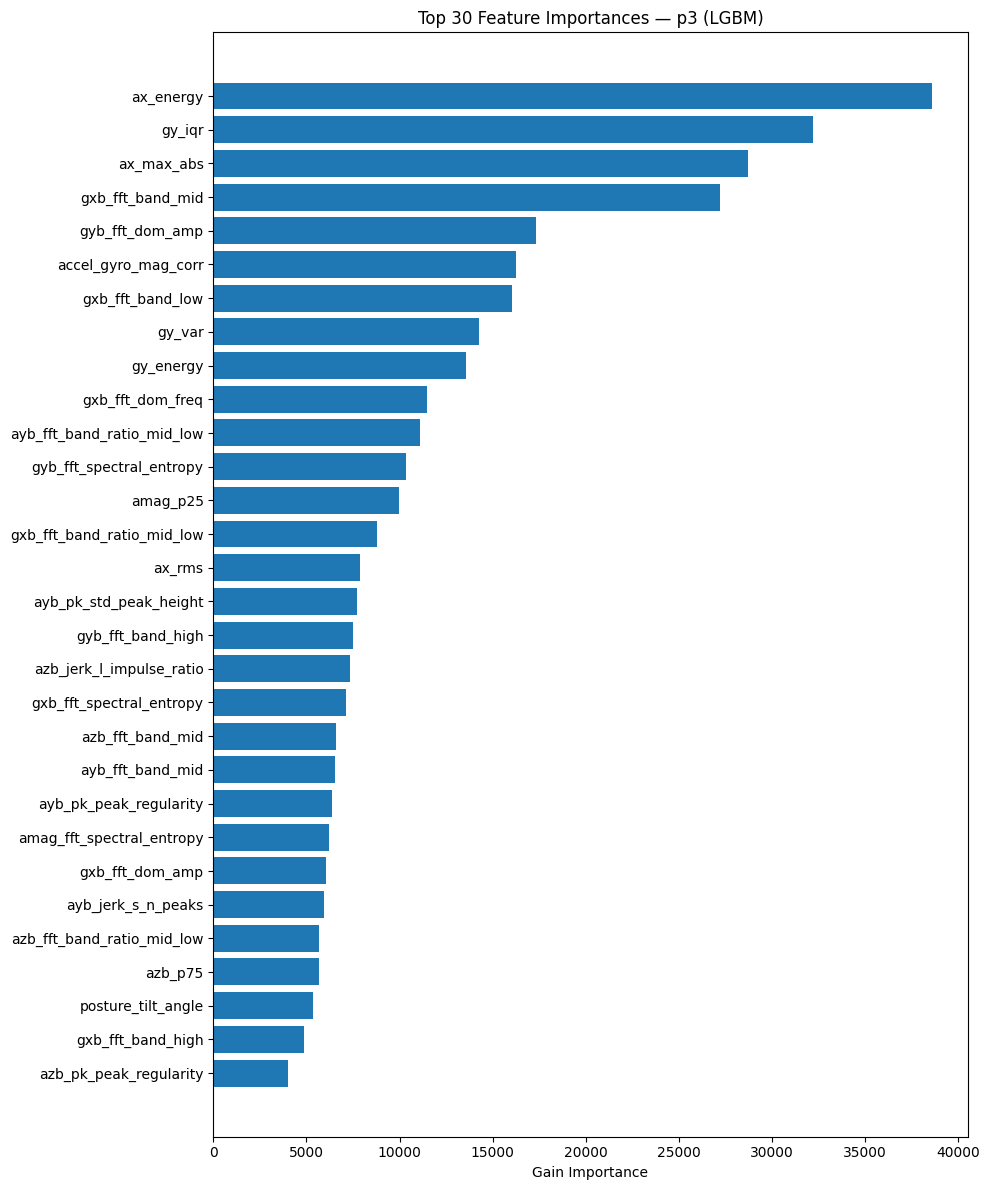

In [18]:
# ── Feature Importance ───────────────────────────────────────
import matplotlib.pyplot as plt

fi = pd.DataFrame({
    'feature':    feat_cols,
    'importance': lgbm_models[-1].feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

print("Top 30 features:")
print(fi.head(30).to_string(index=False))

# Flag new p3 features in the top 30
p3_new = [f for f in fi.head(30)['feature'] if any(tag in f for tag in ['jerk','lat_'])]
print(f"\nNew p3 features in top 30: {p3_new}")

plt.figure(figsize=(10, 12))
plt.barh(fi['feature'].head(30)[::-1], fi['importance'].head(30)[::-1])
plt.xlabel('Gain Importance')
plt.title('Top 30 Feature Importances — p3 (LGBM)')
plt.tight_layout()
plt.show()


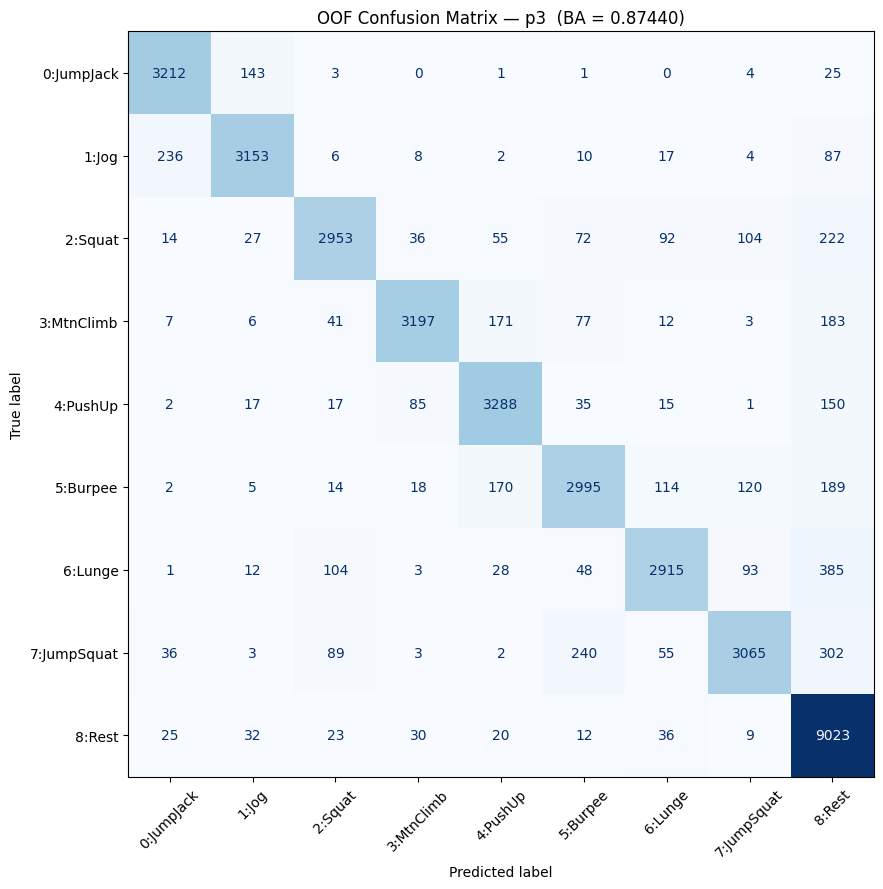


Per-class recall (p3 vs p2):
  0:JumpJack          : 0.948  ▼0.016 vs p2
  1:Jog               : 0.895  ▼0.046 vs p2
  2:Squat             : 0.826  ▼0.039 vs p2
  3:MtnClimb          : 0.865  ▼0.019 vs p2
  4:PushUp            : 0.911  ▼0.007 vs p2
  5:Burpee            : 0.826  ▼0.092 vs p2
  6:Lunge             : 0.812  ▼0.034 vs p2
  7:JumpSquat         : 0.808  ▼0.067 vs p2
  8:Rest              : 0.980  ▲0.015 vs p2

Final OOF BA — p3: 0.87440  (p2 was 0.90851)


In [19]:
# ── OOF Confusion Matrix ─────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = [
    '0:JumpJack','1:Jog','2:Squat','3:MtnClimb',
    '4:PushUp','5:Burpee','6:Lunge','7:JumpSquat','8:Rest'
]

final_oof_preds = oof_preds_smooth if oof_ba_smooth >= oof_ba_raw else oof_preds_raw
final_ba        = balanced_accuracy_score(y_train, final_oof_preds)

cm = confusion_matrix(y_train, final_oof_preds)
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
plt.title(f'OOF Confusion Matrix — p3  (BA = {final_ba:.5f})')
plt.tight_layout()
plt.show()

# Per-class recall vs p2 baseline
p2_recalls = [0.964, 0.941, 0.865, 0.884, 0.918, 0.918, 0.846, 0.875, 0.965]
print("\nPer-class recall (p3 vs p2):")
for i, name in enumerate(class_names):
    r     = cm[i,i] / cm[i].sum() if cm[i].sum() > 0 else 0
    delta = r - p2_recalls[i]
    arrow = '▲' if delta > 0.001 else '▼' if delta < -0.001 else '='
    print(f"  {name:20s}: {r:.3f}  {arrow}{abs(delta):.3f} vs p2")

print(f"\nFinal OOF BA — p3: {final_ba:.5f}  (p2 was 0.90851)")
